In [29]:
using ITensors
using ITensorMPS
using JLD2
using Plots
using LaTeXStrings
using Printf
using Polynomials
using Statistics
using GLM
using DataFrames





In [30]:


data_dir = joinpath(@__DIR__, "data")

# all_data[truncation][sigma] = loaded_data_dict 
all_data = Dict{Float64, Dict{Float64, Any}}() 

sigma_values = [0.0]

trunc_values = [1e-16, 8e-15, 6e-15, 4e-15, 2e-15, 1e-15, 8e-14, 6e-14, 1e-14, 1e-13, 1e-12, 1e-11, 1e-10, 1e-9, 1e-8] 


for trunc in trunc_values
    all_data[trunc] = Dict{Float64, Any}()
    
    for σ in sigma_values
        trunc_str = @sprintf("%.1e", trunc)
        
        # Explicitly format the clean case string
        if σ == 0.0
            sigma_str = "0.0e+00"
        else
            sigma_str = @sprintf("%.1e", σ)
        end

        file_name = "data_fid_$(trunc_str)_$(sigma_str).jld2" 
        file_path = joinpath(data_dir, file_name) 
        
        if isfile(file_path) 
            try
                data = load(file_path)
                all_data[trunc][σ] = data 
                println("Successfully loaded: Trunc=$trunc_str, σ=$sigma_str")
            catch e
                println("ERROR loading file: $file_name -> $e")
            end
        else
            println("File not found: $file_name") 
        end
    end
end


Successfully loaded: Trunc=1.0e-16, σ=0.0e+00
File not found: data_fid_8.0e-15_0.0e+00.jld2
File not found: data_fid_6.0e-15_0.0e+00.jld2
File not found: data_fid_4.0e-15_0.0e+00.jld2
File not found: data_fid_2.0e-15_0.0e+00.jld2
Successfully loaded: Trunc=1.0e-15, σ=0.0e+00
File not found: data_fid_8.0e-14_0.0e+00.jld2
File not found: data_fid_6.0e-14_0.0e+00.jld2
Successfully loaded: Trunc=1.0e-14, σ=0.0e+00
Successfully loaded: Trunc=1.0e-13, σ=0.0e+00
Successfully loaded: Trunc=1.0e-12, σ=0.0e+00
Successfully loaded: Trunc=1.0e-11, σ=0.0e+00
Successfully loaded: Trunc=1.0e-10, σ=0.0e+00
Successfully loaded: Trunc=1.0e-09, σ=0.0e+00
Successfully loaded: Trunc=1.0e-08, σ=0.0e+00


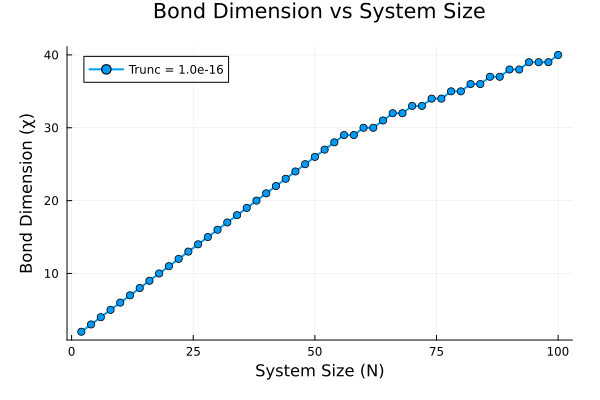

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\bd_trunc_clean.png"

In [31]:
target_sigma = 0.0
target_truncs = [1e-16]

p_bd = plot(
    title = "Bond Dimension vs System Size",
    xlabel = "System Size (N)",
    ylabel = "Bond Dimension (χ)",
    legend = :topleft,    
    margin = 5Plots.mm,
    grid = true
)

for trunc in target_truncs
    if haskey(all_data, trunc) && haskey(all_data[trunc], target_sigma)
        data = all_data[trunc][target_sigma]
        
        N_full = data["N_range"]
        bond_dims_full = data["avg_arr"]
        err_arr_full = data["err_arr"]
        
        mask = bond_dims_full .> 0
        N_vals = N_full[mask]
        bond_dims = bond_dims_full[mask]
        
        if target_sigma == 0.0
            err_bars = nothing
        else
            err_bars = err_arr_full[mask]
        end

        plot!(p_bd, N_vals, bond_dims, 
            yerror = err_bars,
            label = "Trunc = $(trunc)", 
            marker = :circle, 
            linewidth = 2)
    else
        println("Warning: Data not found for sigma = $target_sigma, Trunc = $truncation")
    end
end

display(p_bd)
savefig(p_bd, joinpath("images_report", "bd_trunc_clean.png"))

# Spike trend for different truncations

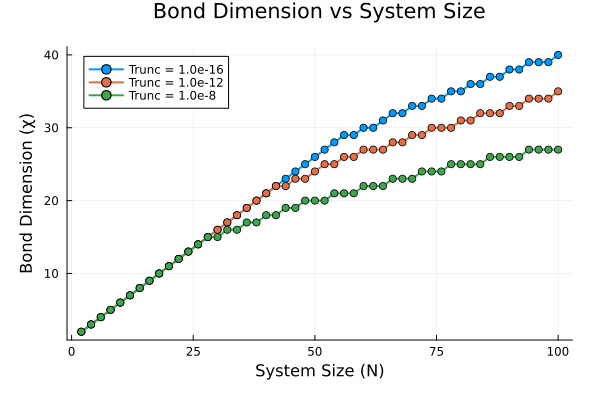

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\bd_truncs_clean.png"

In [32]:
target_sigma = 0.0
target_truncs = [1e-16, 1e-12, 1e-8]

p_bd = plot(
    title = "Bond Dimension vs System Size",
    xlabel = "System Size (N)",
    ylabel = "Bond Dimension (χ)",
    legend = :topleft,    
    margin = 5Plots.mm,
    grid = true
)

for trunc in target_truncs
    if haskey(all_data, trunc) && haskey(all_data[trunc], target_sigma)
        data = all_data[trunc][target_sigma]
        
        N_full = data["N_range"]
        bond_dims_full = data["avg_arr"]
        err_arr_full = data["err_arr"]
        
        mask = bond_dims_full .> 0
        N_vals = N_full[mask]
        bond_dims = bond_dims_full[mask]
        
        if target_sigma == 0.0
            err_bars = nothing
        else
            err_bars = err_arr_full[mask]
        end

        plot!(p_bd, N_vals, bond_dims, 
            yerror = err_bars,
            label = "Trunc = $(trunc)", 
            marker = :circle, 
            linewidth = 2)
    else
        println("Warning: Data not found for sigma = $target_sigma, Trunc = $truncation")
    end
end

display(p_bd)
savefig(p_bd, joinpath("images_report", "bd_truncs_clean.png"))

# Overlay of scaling

In [33]:
# Calculates the f(epsilon) prefactor for the large N approximation
function calculate_f(epsilon)
    return sqrt(0.5 * log(1.0 / epsilon))
end

# 1. Linear Scaling: Exact bond dimension
function chi_exact(N)
    return N / 2.0 + 1.0
end

# 2. Sqrt Scaling: Truncated bond dimension (Large N approximation)
function chi_trunc_approx(N, epsilon)
    return calculate_f(epsilon) * sqrt(N)
end

# 2. Sqrt Scaling: Truncated bond dimension (More rigorous version for small N)
function chi_trunc_rigorous(N, epsilon)
    # Prevents taking the log of zero or negative numbers for very small N
    if N <= 1
        return chi_exact(N)
    end
    term1 = log(1.0 / epsilon)
    term2 = 0.5 * log((pi * N^2) / (8.0 * (N - 1)))
    
    # Ensure the value under the square root is positive
    inner_val = term1 - term2
    if inner_val < 0
        return 0.0
    end
    
    return (N * sqrt(2.0)) / (2.0 * sqrt(N - 1.0)) * sqrt(inner_val)
end

# 3. The predicted scaling function using the minimum of the two regimes
function predict_bond_dimension(N, epsilon; use_rigorous=true)
    exact_val = chi_exact(N)
    
    if use_rigorous
        trunc_val = chi_trunc_rigorous(N, epsilon)
    else
        trunc_val = chi_trunc_approx(N, epsilon)
    end
    
    return min(exact_val, trunc_val)
end

predict_bond_dimension (generic function with 2 methods)

In [34]:
# Define your system sizes and the target truncation threshold
N_values = 1:100
target_truncation = 1e-16

# Generate the predicted scaling data
predicted_scaling = [predict_bond_dimension(N, target_truncation) for N in N_values]



100-element Vector{Float64}:
  1.5
  2.0
  2.5
  3.0
  3.5
  4.0
  4.5
  5.0
  5.5
  6.0
  6.5
  7.0
  7.5
  ⋮
 39.722070922085855
 39.9389371856111
 40.15459863375562
 40.36907492512851
 40.58238519074588
 40.79454805361761
 41.00558164741006
 41.21550363423712
 41.42433122162903
 41.63208117872488
 41.83876985173155
 42.044413178689524

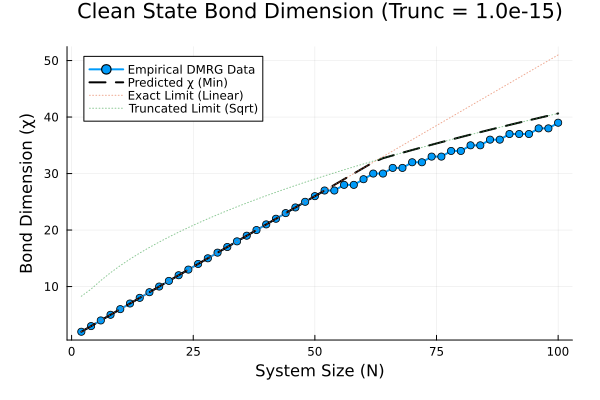

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\clean_chi_scaling_verification.png"

In [35]:
target_trunc = 1e-15
target_sigma = 0.0

if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], target_sigma)
    data = all_data[target_trunc][target_sigma]
    
    bd_key = haskey(data, "bond_dims") ? "bond_dims" : "avg_arr"
    mask = data[bd_key] .> 0 
    
    N_vals = data["N_range"][mask]
    empirical_chi = data[bd_key][mask]
    
    # Calculate predictions using the newly defined functions
    # You can change use_rigorous to false to see the large N approximation
    predicted_chi = [predict_bond_dimension(Float64(N), target_trunc, use_rigorous=true) for N in N_vals]
    
    # Calculate individual limits for the visualisation
    chi_exact_vals = [chi_exact(Float64(N)) for N in N_vals]
    chi_trunc_vals = [chi_trunc_rigorous(Float64(N), target_trunc) for N in N_vals]
    
    p_scale = plot(
        title = "Clean State Bond Dimension (Trunc = $target_trunc)",
        xlabel = "System Size (N)",
        ylabel = "Bond Dimension (χ)",
        legend = :topleft,
        margin = 5Plots.mm,
        grid = true
    )
    
    # Plot empirical data
    plot!(p_scale, N_vals, empirical_chi, 
          label="Empirical DMRG Data", marker=:circle, linewidth=2, color=1)
          
    # Plot predicted min function
    plot!(p_scale, N_vals, predicted_chi, 
          label="Predicted χ (Min)", linestyle=:dash, linewidth=2, color=:black)
          
    # Plot individual bounds for visualisation
    plot!(p_scale, N_vals, chi_exact_vals, 
          label="Exact Limit (Linear)", linestyle=:dot, alpha=0.6, color=2)
    plot!(p_scale, N_vals, chi_trunc_vals, 
          label="Truncated Limit (Sqrt)", linestyle=:dot, alpha=0.6, color=3)
          
    display(p_scale)
    savefig(p_scale, joinpath("images", "clean_chi_scaling_verification.png"))
else
    println("Data not found for Trunc = $target_trunc")
end

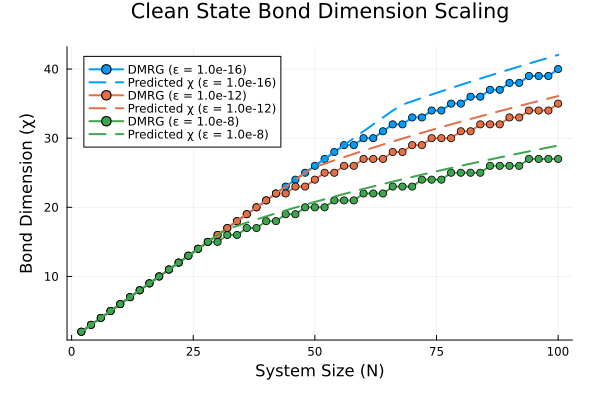

In [36]:
# Calculates the rigorous truncation boundary for small N
function chi_trunc_rigorous(N, epsilon)
    if N <= 1
        return (N / 2.0) + 1.0
    end
    term1 = log(1.0 / epsilon)
    term2 = 0.5 * log((pi * N^2) / (8.0 * (N - 1.0)))
    
    inner_val = term1 - term2
    if inner_val < 0
        return 0.0
    end
    
    return (N * sqrt(2.0)) / (2.0 * sqrt(N - 1.0)) * sqrt(inner_val)
end

# Predicts the final bond dimension using the minimum of the two scaling regimes
function predict_bond_dimension(N::Float64, epsilon::Float64)
    chi_exact = (N / 2.0) + 1.0
    chi_trunc = chi_trunc_rigorous(N, epsilon)
    return min(chi_exact, chi_trunc)
end

target_trunc_list = [1e-16, 1e-12, 1e-8] 
target_sigma = 0.0

p_scale = plot(
    title = "Clean State Bond Dimension Scaling",
    xlabel = "System Size (N)",
    ylabel = "Bond Dimension (χ)",
    legend = :topleft,
    margin = 5Plots.mm,
    grid = true
)

for (i, target_trunc) in enumerate(target_trunc_list)
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], target_sigma)
        data = all_data[target_trunc][target_sigma]
        bd_key = haskey(data, "bond_dims") ? "bond_dims" : "avg_arr"
        mask = data[bd_key] .> 0 
        
        N_vals = data["N_range"][mask]
        empirical_chi = data[bd_key][mask]
        
        # Generate predictions using the rigorous model
        predicted_chi_vals = [predict_bond_dimension(Float64(N), target_trunc) for N in N_vals]
        
        # Plot empirical data with unique colour per truncation
        plot!(p_scale, N_vals, empirical_chi, 
              label="DMRG (ε = $target_trunc)", 
              marker=:circle, linewidth=2, color=palette(:default)[i])
              
        # Plot predicted data matching the empirical colour, in a dashed style
        plot!(p_scale, N_vals, predicted_chi_vals, 
              label="Predicted χ (ε = $target_trunc)", 
              linestyle=:dash, linewidth=2, color=palette(:default)[i])
    else
        println("Data not found for Trunc = $target_trunc")
    end
end

display(p_scale)

# Spectra

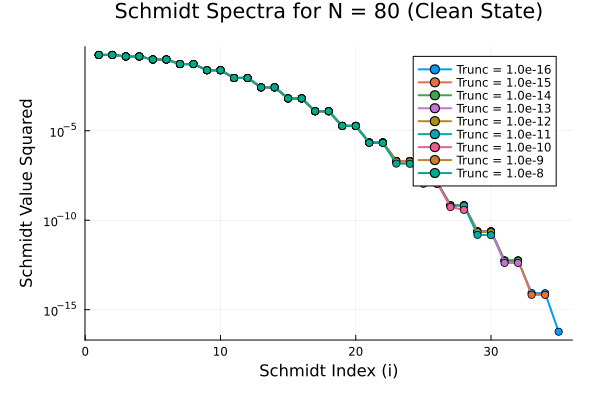

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\spectra_clean_truncations_N=80.png"

In [37]:
target_truncs = [1e-16, 8e-16, 1e-15, 2e-15, 4e-15, 6e-15, 1e-14, 2e-14, 4e-14, 6e-14, 8e-14, 1e-13, 1e-12, 1e-11, 1e-10, 1e-9, 1e-8]
target_sigma = 0.0
target_N = 80

p_spectra = plot(
    title = "Schmidt Spectra for N = $target_N (Clean State)",
    xlabel = "Schmidt Index (i)",
    ylabel = "Schmidt Value Squared",
    legend = :topright,
    yscale = :log10,
    margin = 5Plots.mm,
    grid = true
)

for trunc in target_truncs
    if haskey(all_data, trunc) && haskey(all_data[trunc], target_sigma)
        data = all_data[trunc][target_sigma]
        
        N_full = data["N_range"]
        idx = findfirst(==(target_N), N_full)
        
        if !isnothing(idx)
            # Accommodates both the new clean script output and the old array structure
            spectra_full = haskey(data, "spectra") ? data["spectra"] : data["spectra_avg"]
            spectra_vals = spectra_full[idx, :]
            
            valid_spectra = filter(x -> x > 0, spectra_vals)
            sorted_spectra = sort(valid_spectra, rev=true)
            
            plot!(p_spectra, 1:length(sorted_spectra), sorted_spectra, 
                label = "Trunc = $(trunc)", 
                marker = :circle, 
                linewidth = 2)
        else
            println("Warning: N = $target_N not found for Trunc = $trunc")
        end
    else
        println("Warning: Data not found for Trunc = $trunc, σ = $target_sigma")
    end
end

display(p_spectra)
savefig(p_spectra, joinpath("images", "spectra_clean_truncations_N=$target_N.png"))

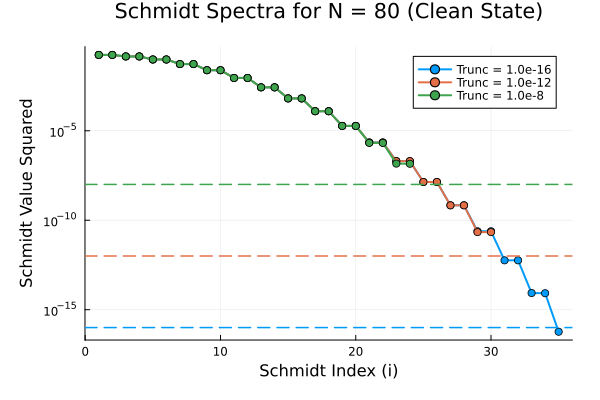

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\spectra_clean_truncations_N=80.png"

In [38]:
target_truncs = [1e-16, 1e-12, 1e-8]
target_sigma = 0.0
target_N = 80

p_spectra = plot(
    title = "Schmidt Spectra for N = $target_N (Clean State)",
    xlabel = "Schmidt Index (i)",
    ylabel = "Schmidt Value Squared",
    legend = :topright,
    yscale = :log10,
    margin = 5Plots.mm,
    grid = true
)

for (i, trunc) in enumerate(target_truncs)
    if haskey(all_data, trunc) && haskey(all_data[trunc], target_sigma)
        data = all_data[trunc][target_sigma]
        
        N_full = data["N_range"]
        idx = findfirst(==(target_N), N_full)
        
        if !isnothing(idx)
            # Accommodates both the new clean script output and the old array structure
            spectra_full = haskey(data, "spectra") ? data["spectra"] : data["spectra_avg"]
            spectra_vals = spectra_full[idx, :]
            
            valid_spectra = filter(x -> x > 0, spectra_vals)
            sorted_spectra = sort(valid_spectra, rev=true)
            
            # Plot the spectra using 'i' for colour index to keep it consistent
            plot!(p_spectra, 1:length(sorted_spectra), sorted_spectra, 
                label = "Trunc = $(trunc)", 
                marker = :circle, 
                linewidth = 2,
                color = i)
                
            # Plot the horizontal truncation line with the matching colour
            hline!(p_spectra, [trunc], 
                label = "", 
                linestyle = :dash, 
                linewidth = 1.5,
                color = i)
        else
            println("Warning: N = $target_N not found for Trunc = $trunc")
        end
    else
        println("Warning: Data not found for Trunc = $trunc, σ = $target_sigma")
    end
end

display(p_spectra)
savefig(p_spectra, joinpath("images", "spectra_clean_truncations_N=$target_N.png"))

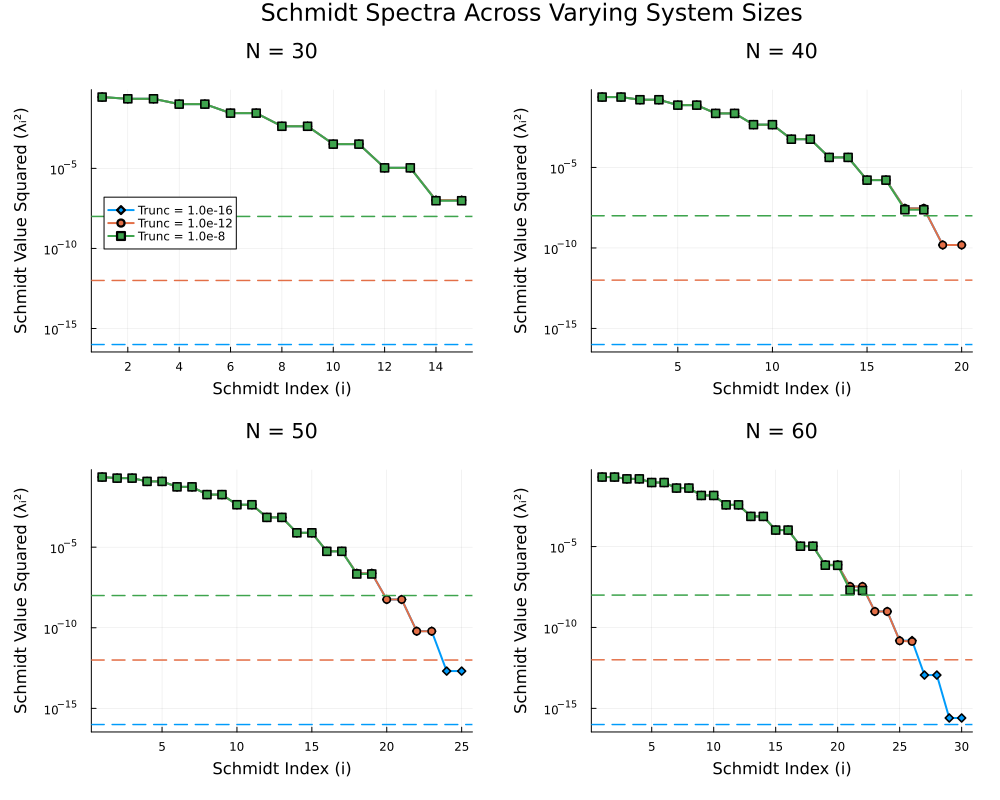

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\spectra_clean_truncations_grid.png"

In [39]:
target_truncs = [1e-16, 1e-12, 1e-8]
target_sigma = 0.0
target_Ns = [30, 40, 50, 60]

subplots = []

for (j, target_N) in enumerate(target_Ns)
    p_sub = plot(
        title = "N = $target_N",
        xlabel = "Schmidt Index (i)",
        ylabel = "Schmidt Value Squared (λᵢ²)",
        legend = j == 1 ? :left : false, 
        yscale = :log10,
        grid = true
    )
    
    for (i, trunc) in enumerate(target_truncs)
        if haskey(all_data, trunc) && haskey(all_data[trunc], target_sigma)
            data = all_data[trunc][target_sigma]
            
            N_full = data["N_range"]
            idx = findfirst(==(target_N), N_full)
            
            if !isnothing(idx)
                spectra_full = haskey(data, "spectra") ? data["spectra"] : data["spectra_avg"]
                spectra_vals = spectra_full[idx, :]
                
                valid_spectra = filter(x -> x > 0, spectra_vals)
                sorted_spectra = sort(valid_spectra, rev=true)
                
                markerstyle = i == 1 ? :diamond : i ==2  ? :circle : :square

                # Plot the spectra using 'i' for colour index to keep it consistent
                plot!(p_sub, 1:length(sorted_spectra), sorted_spectra, 
                    label = j == 1 ? "Trunc = $(trunc)" : "", 
                    marker = markerstyle, 
                    linewidth = 2,
                    color = i)
                    
                # Plot the horizontal truncation line with the matching colour
                hline!(p_sub, [trunc], 
                    label = "", 
                    linestyle = :dash, 
                    linewidth = 1.5,
                    color = i)
            else
                println("Warning: N = $target_N not found for Trunc = $trunc")
            end
        else
            println("Warning: Data not found for Trunc = $trunc, σ = $target_sigma")
        end
    end
    
    push!(subplots, p_sub)
end

# Combine into a 2x2 grid, add margins, and include an overall title
p_spectra = plot(subplots..., 
    layout = (2, 2), 
    size = (1000, 800), 
    margin = 5Plots.mm,
    plot_title = "Schmidt Spectra Across Varying System Sizes"
)

display(p_spectra)
savefig(p_spectra, joinpath("images_report", "spectra_clean_truncations_grid.png"))

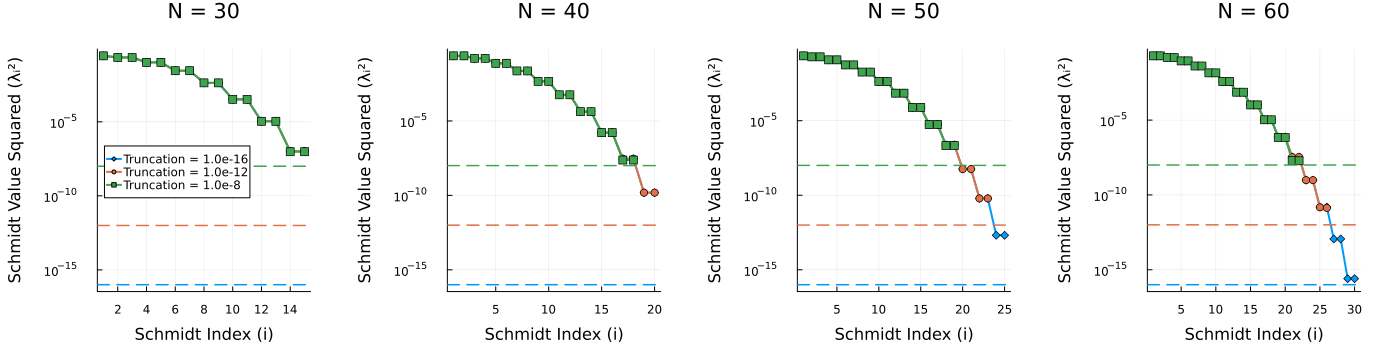

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\spectra_clean_truncations_1x4.png"

In [40]:
target_truncs = [1e-16, 1e-12, 1e-8]
target_sigma = 0.0
target_Ns = [30, 40, 50, 60]

subplots = []

for (j, target_N) in enumerate(target_Ns)
    p_sub = plot(
        title = "N = $target_N",
        xlabel = "Schmidt Index (i)",
        ylabel = "Schmidt Value Squared (λᵢ²)",
        legend = j == 1 ? :left : false, 
        yscale = :log10,
        grid = true
    )
    
    for (i, trunc) in enumerate(target_truncs)
        if haskey(all_data, trunc) && haskey(all_data[trunc], target_sigma)
            data = all_data[trunc][target_sigma]
            
            N_full = data["N_range"]
            idx = findfirst(==(target_N), N_full)
            
            if !isnothing(idx)
                spectra_full = haskey(data, "spectra") ? data["spectra"] : data["spectra_avg"]
                spectra_vals = spectra_full[idx, :]
                
                valid_spectra = filter(x -> x > 0, spectra_vals)
                sorted_spectra = sort(valid_spectra, rev=true)
                
                markerstyle = i == 1 ? :diamond : i ==2  ? :circle : :square

                # Plot the spectra using 'i' for colour index to keep it consistent
                plot!(p_sub, 1:length(sorted_spectra), sorted_spectra, 
                    label = j == 1 ? "Truncation = $(trunc)" : "", 
                    marker = markerstyle, 
                    linewidth = 2,
                    color = i)
                    
                # Plot the horizontal truncation line with the matching colour
                hline!(p_sub, [trunc], 
                    label = "", 
                    linestyle = :dash, 
                    linewidth = 1.5,
                    color = i)
            else
                println("Warning: N = $target_N not found for Trunc = $trunc")
            end
        else
            println("Warning: Data not found for Trunc = $trunc, σ = $target_sigma")
        end
    end
    
    push!(subplots, p_sub)
end

# Combine into a 1x4 grid, adjust size for horizontal span, add margins, and include an overall title
p_spectra = plot(subplots..., 
    layout = (1, 4), 
    size = (1400, 350), 
    # plot_title = "Schmidt Spectra Across Varying System Sizes",
    margin = 8Plots.mm
)

display(p_spectra)
savefig(p_spectra, joinpath("images_report", "spectra_clean_truncations_1x4.png"))

# Entropies

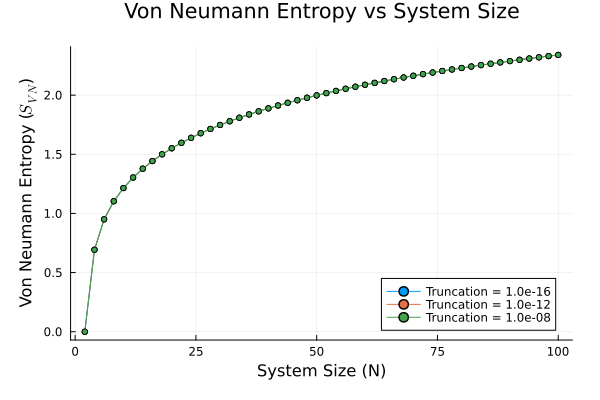

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\S_VN_clean.png"

In [41]:
p_vn = plot(
    title = "Von Neumann Entropy vs System Size",
    xlabel = "System Size (N)",
    ylabel = L"Von Neumann Entropy ($S_{VN}$)",
    legend = :bottomright,
    grid = true,
    margin = 5Plots.mm
)

target_sigma = 0.0
chosen_truncs = [1e-16, 1e-12, 1e-8]

for trunc in chosen_truncs
    if haskey(all_data[trunc], target_sigma)
        data = all_data[trunc][target_sigma]
        N_range = collect(2:2:length(data["vn_avg"])*2) 
        
        plot!(p_vn, N_range, data["vn_avg"], 
              ribbon = data["vn_err"],
              label = "Truncation = $(@sprintf("%.1e", trunc))",
              marker = :circle, markersize = 3)
    end
end

display(p_vn)
savefig(p_vn, joinpath("images_report", "S_VN_clean.png"))

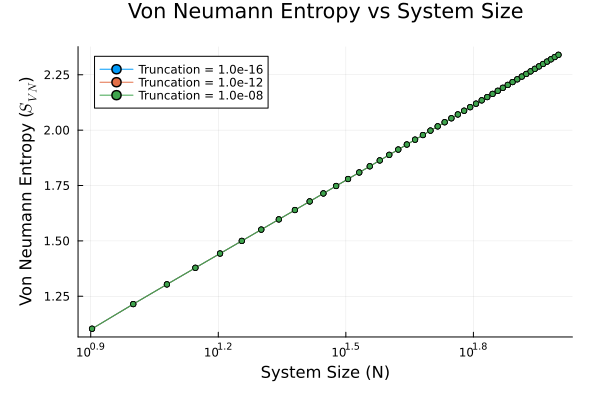

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\S_VN_clean_log.png"

In [42]:
p_vn = plot(
    title = "Von Neumann Entropy vs System Size",
    xlabel = "System Size (N)",
    ylabel = L"Von Neumann Entropy ($S_{VN}$)",
    legend = :topleft,
    xaxis = :log10,
    grid = true,
    margin = 5Plots.mm
)

target_sigma = 0.0
chosen_truncs = [1e-16, 1e-12, 1e-8]
start_N = 8 # Define your starting N here

for trunc in chosen_truncs
    if haskey(all_data[trunc], target_sigma)
        data = all_data[trunc][target_sigma]
        
        # Generate the full range
        N_range_full = collect(2:2:length(data["vn_avg"])*2) 
        
        # Find indices where N is greater than or equal to start_N
        valid_indices = findall(x -> x >= start_N, N_range_full)
        
        # Filter the arrays using the valid indices
        N_range = N_range_full[valid_indices]
        vn_avg = data["vn_avg"][valid_indices]
        vn_err = data["vn_err"][valid_indices]
        
        plot!(p_vn, N_range, vn_avg, 
              ribbon = vn_err,
              label = "Truncation = $(@sprintf("%.1e", trunc))",
              marker = :circle, markersize = 3)
    end
end

display(p_vn)
savefig(p_vn, joinpath("images_report", "S_VN_clean_log.png"))

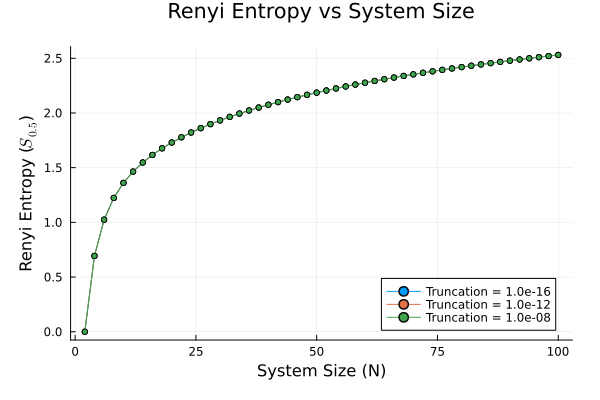

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\S_05_clean.png"

In [43]:
# Plotting Renyi Entropy (alpha=0.5) for multiple truncations
p_s05 = plot(
    title = "Renyi Entropy vs System Size",
    xlabel = "System Size (N)",
    ylabel = L"Renyi Entropy ($S_{0.5}$)",
    legend = :bottomright,
    grid = true,
    margin = 5Plots.mm
)

for trunc in chosen_truncs
    if haskey(all_data[trunc], target_sigma)
        data = all_data[trunc][target_sigma]
        N_range = collect(2:2:length(data["s05_avg"])*2)
        
        plot!(p_s05, N_range, data["s05_avg"], 
              ribbon = data["s05_err"],
              label = "Truncation = $(@sprintf("%.1e", trunc))",
              marker = :circle, markersize = 3)
    end
end

display(p_s05)
savefig(p_s05, joinpath("images_report", "S_05_clean.png"))

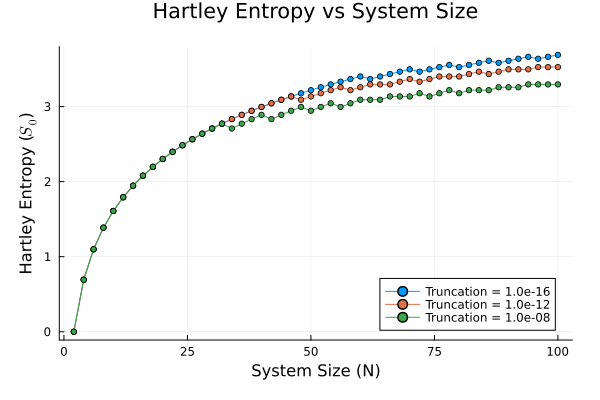

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\S_0_clean.png"

In [44]:
# Plotting Hartley Entropy (alpha=0) for multiple truncations
p_s0 = plot(
    title = "Hartley Entropy vs System Size",
    xlabel = "System Size (N)",
    ylabel = L"Hartley Entropy ($S_{0}$)",
    legend = :bottomright,
    grid = true,
    margin = 5Plots.mm
)

for trunc in chosen_truncs
    if haskey(all_data[trunc], target_sigma)
        data = all_data[trunc][target_sigma]
        N_range = collect(2:2:length(data["s0_avg"])*2)
        
        plot!(p_s0, N_range, data["s0_avg"], 
              ribbon = data["s0_err"],
              label = "Truncation = $(@sprintf("%.1e", trunc))",
              marker = :circle, markersize = 3)
    end
end

display(p_s0)
savefig(p_s0, joinpath("images_report", "S_0_clean.png"))

# Deviation from linear

In [45]:
"""
    get_clean_scaling_indices(all_data, target_trunc)

Refined logic using Bond Dimension (avg_arr) to find the saturation point.
Returns the actual system size (N) at deviation, and the corresponding array indices.
"""
function get_clean_scaling_indices(all_data, target_trunc)
    if !haskey(all_data, target_trunc) || !haskey(all_data[target_trunc], 0.0)
        error("Data for truncation $target_trunc and sigma 0.0 not found.")
    end
    
    data = all_data[target_trunc][0.0]
    vn_avg = data["vn_avg"]
    bond_dims = data["avg_arr"] 
    
    transition_idx = length(vn_avg)
    
    # We look for where the ratio of consecutive bond dimensions drops 
    # significantly below the initial exponential growth ratio.
    for i in 2:(length(bond_dims)-1)
        growth_ratio = bond_dims[i+1] / bond_dims[i]
        
        # If growth drops below a 1% increase (saturation)
        if growth_ratio < 1.01
            transition_idx = i
            break
        end
    end
    
    # Double the index because the system size increments by 2 each step
    deviation_N = transition_idx * 2 
    
    head_indices = 1:transition_idx
    tail_indices = (transition_idx + 1):length(vn_avg)
    
    return deviation_N, head_indices, tail_indices
end

function get_deviation_index(all_data, target_trunc)
    try
        deviation_N, head, tail = get_clean_scaling_indices(all_data, target_trunc)
        
        return deviation_N, head, tail
        
    catch e
        println("Could not find deviation for Trunc $(target_trunc): $(e.msg)")
        return nothing, nothing, nothing
    end
end

target_trunc = 1e-16
deviation_N, head_vals, tail_vals = get_deviation_index(all_data, target_trunc)

if !isnothing(deviation_N)
    println("Deviation from linear scaling occurs at N = $deviation_N")
    println("Head array indices: ", head_vals)
    println("Tail array indices: ", tail_vals)
else
    println("Could not determine deviation index for Trunc = $target_trunc")
end

Deviation from linear scaling occurs at N = 56
Head array indices: 1:28
Tail array indices: 29:50


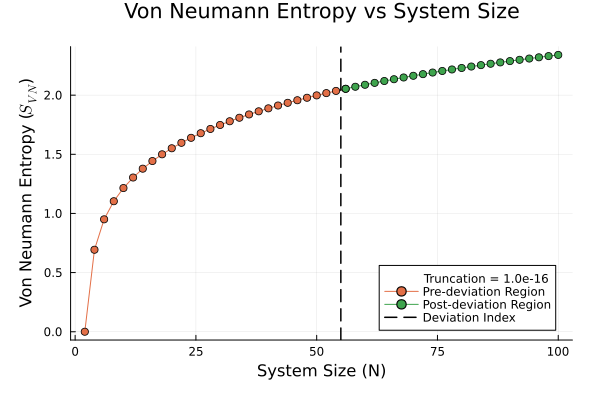

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\S_VN_clean_deviation.png"

In [46]:
target_trunc = 1e-16 
target_sigma = 0.0
start_N = 2

deviation_N, head_indices, tail_indices = get_deviation_index(all_data, target_trunc)

p_vn = plot(
    title = "Von Neumann Entropy vs System Size",
    xlabel = "System Size (N)",
    ylabel = L"Von Neumann Entropy ($S_{VN}$)",
    legend = :bottomright,
    # xaxis = :log10,
    grid = true,
    margin = 5Plots.mm
)

if !isnothing(deviation_N) && haskey(all_data[target_trunc], target_sigma)
    data = all_data[target_trunc][target_sigma]
    
    N_range_full = collect(2:2:length(data["vn_avg"])*2) 
    vn_avg_full = data["vn_avg"]
    vn_err_full = data["vn_err"]
    
    valid_start_indices = findall(x -> x >= start_N, N_range_full)
    
    plot_head_indices = intersect(valid_start_indices, head_indices)
    
    transition_idx = last(head_indices)
    plot_tail_indices = intersect(valid_start_indices, [transition_idx; collect(tail_indices)])
    
    # Add an invisible series to create a text-only legend entry
    plot!(p_vn, [NaN], [NaN], 
          label = "Truncation = $target_trunc", 
          linealpha = 0, 
          markeralpha = 0)

    if !isempty(plot_head_indices)
        plot!(p_vn, N_range_full[plot_head_indices], vn_avg_full[plot_head_indices], 
              ribbon = vn_err_full[plot_head_indices],
              label = "Pre-deviation Region",
              marker = :circle, markersize = 4)
    end
          
    if !isempty(plot_tail_indices)
        plot!(p_vn, N_range_full[plot_tail_indices], vn_avg_full[plot_tail_indices], 
              ribbon = vn_err_full[plot_tail_indices],
              label = "Post-deviation Region",
              marker = :circle, markersize = 4)
    end

    vline!(p_vn, [deviation_N - 1], 
           color = :black, 
           linestyle = :dash, 
           linewidth = 1.5,
           label = "Deviation Index")

    

else
    println("Warning: Data or deviation point not found for Trunc = $target_trunc")
end

display(p_vn)
savefig(p_vn, joinpath("images_report", "S_VN_clean_deviation.png"))

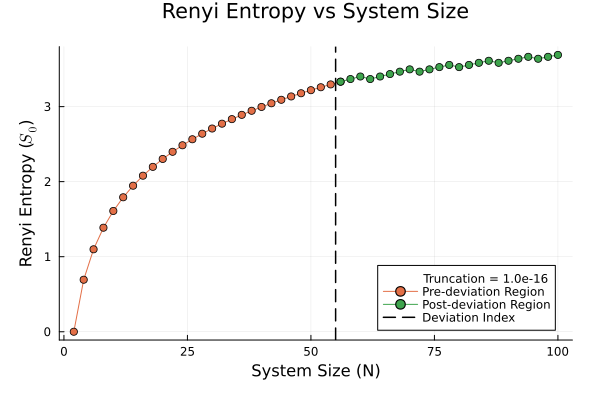

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\S_VN_clean_deviation.png"

In [47]:
target_trunc = 1e-16 
target_sigma = 0.0
start_N = 2

deviation_N, head_indices, tail_indices = get_deviation_index(all_data, target_trunc)

p_vn = plot(
    title = "Renyi Entropy vs System Size",
    xlabel = "System Size (N)",
    ylabel = L"Renyi Entropy ($S_{0}$)",
    legend = :bottomright,
    # xaxis = :log10,
    grid = true,
    margin = 5Plots.mm
)

if !isnothing(deviation_N) && haskey(all_data[target_trunc], target_sigma)
    data = all_data[target_trunc][target_sigma]
    
    N_range_full = collect(2:2:length(data["s0_avg"])*2) 
    vn_avg_full = data["s0_avg"]
    vn_err_full = data["s0_err"]
    
    valid_start_indices = findall(x -> x >= start_N, N_range_full)
    
    plot_head_indices = intersect(valid_start_indices, head_indices)
    
    transition_idx = last(head_indices)
    plot_tail_indices = intersect(valid_start_indices, [transition_idx; collect(tail_indices)])
    
    # Add an invisible series to create a text-only legend entry
    plot!(p_vn, [NaN], [NaN], 
          label = "Truncation = $target_trunc", 
          linealpha = 0, 
          markeralpha = 0)

    if !isempty(plot_head_indices)
        plot!(p_vn, N_range_full[plot_head_indices], vn_avg_full[plot_head_indices], 
              ribbon = vn_err_full[plot_head_indices],
              label = "Pre-deviation Region",
              marker = :circle, markersize = 4)
    end
          
    if !isempty(plot_tail_indices)
        plot!(p_vn, N_range_full[plot_tail_indices], vn_avg_full[plot_tail_indices], 
              ribbon = vn_err_full[plot_tail_indices],
              label = "Post-deviation Region",
              marker = :circle, markersize = 4)
    end

    vline!(p_vn, [deviation_N - 1], 
           color = :black, 
           linestyle = :dash, 
           linewidth = 1.5,
           label = "Deviation Index")

    

else
    println("Warning: Data or deviation point not found for Trunc = $target_trunc")
end

display(p_vn)
savefig(p_vn, joinpath("images_report", "S_VN_clean_deviation.png"))

Calculating deviation indices for all truncations:
Truncation: 1.0e-16 -> Deviation N = 56
Truncation: 1.0e-15 -> Deviation N = 52
Could not find deviation for Trunc 2.0e-15: Data for truncation 2.0e-15 and sigma 0.0 not found.
Skipping Truncation: 2.0e-15 (Deviation not found)
Could not find deviation for Trunc 4.0e-15: Data for truncation 4.0e-15 and sigma 0.0 not found.
Skipping Truncation: 4.0e-15 (Deviation not found)
Could not find deviation for Trunc 6.0e-15: Data for truncation 6.0e-15 and sigma 0.0 not found.
Skipping Truncation: 6.0e-15 (Deviation not found)
Could not find deviation for Trunc 8.0e-15: Data for truncation 8.0e-15 and sigma 0.0 not found.
Skipping Truncation: 8.0e-15 (Deviation not found)
Truncation: 1.0e-14 -> Deviation N = 48
Could not find deviation for Trunc 6.0e-14: Data for truncation 6.0e-14 and sigma 0.0 not found.
Skipping Truncation: 6.0e-14 (Deviation not found)
Could not find deviation for Trunc 8.0e-14: Data for truncation 8.0e-14 and sigma 0.0 not

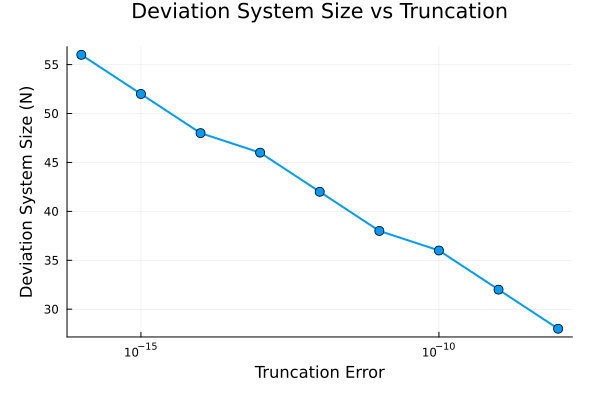

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\deviation_N_vs_truncation.png"

In [48]:
using Printf

# Initialise empty arrays to store the valid data points
trunc_vals = Float64[]
dev_N_vals = Int[]

# Retrieve and sort all available truncations from the dataset
sorted_truncs = sort(collect(keys(all_data)))

println("Calculating deviation indices for all truncations:")

for trunc in sorted_truncs
    deviation_N, head, tail = get_deviation_index(all_data, trunc)
    
    if !isnothing(deviation_N)
        push!(trunc_vals, trunc)
        push!(dev_N_vals, deviation_N)
        
        # Optional print statement to log the progress
        println("Truncation: $(@sprintf("%.1e", trunc)) -> Deviation N = $deviation_N")
    else
        println("Skipping Truncation: $(@sprintf("%.1e", trunc)) (Deviation not found)")
    end
end

# Plot the deviation system size as a function of truncation
p_dev = plot(
    trunc_vals, dev_N_vals,
    title = "Deviation System Size vs Truncation",
    xlabel = "Truncation Error",
    ylabel = "Deviation System Size (N)",
    xscale = :log10, 
    marker = :circle,
    markersize = 5,
    linewidth = 2,
    legend = false,
    grid = true,
    margin = 5Plots.mm
)

display(p_dev)
savefig(p_dev, joinpath("images_report", "deviation_N_vs_truncation.png"))

Truncation: 1.0e-16 -> Deviation N = 56
Truncation: 1.0e-15 -> Deviation N = 52
Could not find deviation for Trunc 2.0e-15: Data for truncation 2.0e-15 and sigma 0.0 not found.
Could not find deviation for Trunc 4.0e-15: Data for truncation 4.0e-15 and sigma 0.0 not found.
Could not find deviation for Trunc 6.0e-15: Data for truncation 6.0e-15 and sigma 0.0 not found.
Could not find deviation for Trunc 8.0e-15: Data for truncation 8.0e-15 and sigma 0.0 not found.
Truncation: 1.0e-14 -> Deviation N = 48
Could not find deviation for Trunc 6.0e-14: Data for truncation 6.0e-14 and sigma 0.0 not found.
Could not find deviation for Trunc 8.0e-14: Data for truncation 8.0e-14 and sigma 0.0 not found.
Truncation: 1.0e-13 -> Deviation N = 46
Truncation: 1.0e-12 -> Deviation N = 42
Truncation: 1.0e-11 -> Deviation N = 38
Truncation: 1.0e-10 -> Deviation N = 36
Truncation: 1.0e-09 -> Deviation N = 32
Truncation: 1.0e-08 -> Deviation N = 28
Line of best fit calculated successfully.


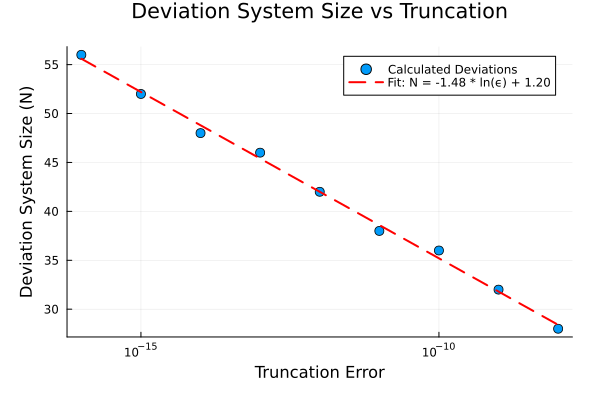

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\deviation_N_vs_truncation_fit.png"

In [49]:
using Printf

# Retrieve and sort all available truncations from the dataset
sorted_truncs = sort(collect(keys(all_data)))


# Store pairs together in a single array to guarantee lengths always match exactly
valid_data = []

for trunc in sorted_truncs
    deviation_N, head, tail = get_deviation_index(all_data, trunc)
    
    if !isnothing(deviation_N)
        # Push as a paired tuple
        push!(valid_data, (trunc, Float64(deviation_N)))
        
        println("Truncation: $(@sprintf("%.1e", trunc)) -> Deviation N = $deviation_N")
    else

    end
end

# Extract them into two guaranteed identical-length arrays
trunc_vals = [pair[1] for pair in valid_data]
dev_N_vals = [pair[2] for pair in valid_data]

# Calculate the line of best fit (N = m * log10(trunc) + c)
log_truncs = log.(trunc_vals)

# Create the design matrix for linear regression: [1, log_trunc]
A = hcat(ones(length(log_truncs)), log_truncs)

# Solve for the coefficients [c, m] using least squares
coeffs = A \ dev_N_vals
c = coeffs[1]
m = coeffs[2]

# Generate the fitted y-values
fit_N_vals = c .+ m .* log_truncs

# Create a dynamic label for the legend
fit_label = @sprintf("Fit: N = %.2f * ln(ϵ) + %.2f", m, c)
println("Line of best fit calculated successfully.")

# Plot the original data points
p_dev = scatter(
    trunc_vals, dev_N_vals,
    title = "Deviation System Size vs Truncation",
    xlabel = "Truncation Error",
    ylabel = "Deviation System Size (N)",
    xscale = :log10, 
    marker = :circle,
    markersize = 5,
    label = "Calculated Deviations",
    legend = :topright,
    grid = true,
    margin = 5Plots.mm
)

# Overlay the line of best fit using our dynamic label
plot!(p_dev, trunc_vals, fit_N_vals,
      linewidth = 2,
      color = :red,
      linestyle = :dash,
      label = fit_label)

display(p_dev)
savefig(p_dev, joinpath("images_report", "deviation_N_vs_truncation_fit.png"))

Calculating deviation indices for all truncations:
Truncation: 1.0e-16 -> Deviation N = 56
Truncation: 1.0e-15 -> Deviation N = 52
Could not find deviation for Trunc 2.0e-15: Data for truncation 2.0e-15 and sigma 0.0 not found.
Skipping Truncation: 2.0e-15 (Deviation not found)
Could not find deviation for Trunc 4.0e-15: Data for truncation 4.0e-15 and sigma 0.0 not found.
Skipping Truncation: 4.0e-15 (Deviation not found)
Could not find deviation for Trunc 6.0e-15: Data for truncation 6.0e-15 and sigma 0.0 not found.
Skipping Truncation: 6.0e-15 (Deviation not found)
Could not find deviation for Trunc 8.0e-15: Data for truncation 8.0e-15 and sigma 0.0 not found.
Skipping Truncation: 8.0e-15 (Deviation not found)
Truncation: 1.0e-14 -> Deviation N = 48
Could not find deviation for Trunc 6.0e-14: Data for truncation 6.0e-14 and sigma 0.0 not found.
Skipping Truncation: 6.0e-14 (Deviation not found)
Could not find deviation for Trunc 8.0e-14: Data for truncation 8.0e-14 and sigma 0.0 not

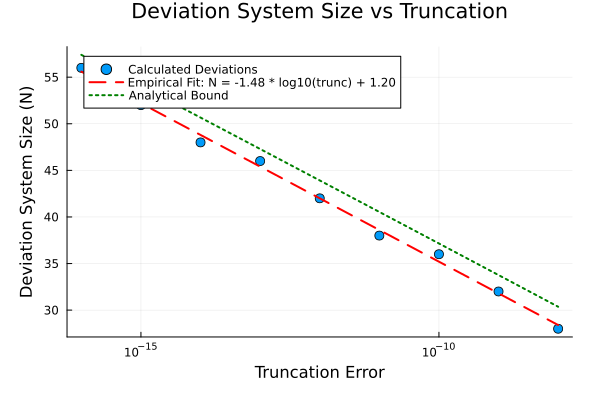

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\deviation_N_vs_truncation_analytical.png"

In [50]:
using Printf

# Helper function to solve the implicit analytical equation for N
function calculate_analytical_N(trunc)
    # The equation simplifies to N = -log2(trunc) + 0.5 * log2(2 * pi * N)
    # We use the first term as our initial guess
    N_val = -log2(trunc)
    
    # Iterate until the value converges (this usually takes fewer than 10 steps)
    for i in 1:100
        N_next = -log2(trunc) + 0.5 * log2(2 * pi * N_val)
        if abs(N_next - N_val) < 1e-5
            return N_next
        end
        N_val = N_next
    end
    return N_val
end

# Retrieve and sort all available truncations from the dataset
sorted_truncs = sort(collect(keys(all_data)))

println("Calculating deviation indices for all truncations:")

# Store pairs together in a single array to guarantee lengths always match exactly
valid_data = []

for trunc in sorted_truncs
    deviation_N, head, tail = get_deviation_index(all_data, trunc)
    
    if !isnothing(deviation_N)
        push!(valid_data, (trunc, Float64(deviation_N)))
        println("Truncation: $(@sprintf("%.1e", trunc)) -> Deviation N = $deviation_N")
    else
        println("Skipping Truncation: $(@sprintf("%.1e", trunc)) (Deviation not found)")
    end
end

# Extract them into two guaranteed identical-length arrays
trunc_vals = [pair[1] for pair in valid_data]
dev_N_vals = [pair[2] for pair in valid_data]

# Calculate the empirical line of best fit (N = m * log10(trunc) + c)
log_truncs = log.(trunc_vals)
A = hcat(ones(length(log_truncs)), log_truncs)
coeffs = A \ dev_N_vals
c = coeffs[1]
m = coeffs[2]

# Create a dynamic label for the empirical fit
fit_label = @sprintf("Empirical Fit: N = %.2f * log10(trunc) + %.2f", m, c)
println("Line of best fit calculated successfully.")

# Generate a dense, smooth range of truncations for the overlay lines
min_log = log(minimum(trunc_vals))
max_log = log(maximum(trunc_vals))
smooth_truncs = ℯ .^ range(min_log, stop=max_log, length=100)

# Calculate the y-values for both the empirical fit and the analytical bound
smooth_fit_N = c .+ m .* log.(smooth_truncs)
analytical_N_vals = calculate_analytical_N.(smooth_truncs)

# Plot the original data points
p_dev = scatter(
    trunc_vals, dev_N_vals,
    title = "Deviation System Size vs Truncation",
    xlabel = "Truncation Error",
    ylabel = "Deviation System Size (N)",
    xscale = :log10, 
    marker = :circle,
    markersize = 5,
    label = "Calculated Deviations",
    legend = :topleft,
    grid = true,
    margin = 5Plots.mm
)

# Overlay the empirical line of best fit
plot!(p_dev, smooth_truncs, smooth_fit_N,
      linewidth = 2,
      color = :red,
      linestyle = :dash,
      label = fit_label)

# Overlay the analytical theoretical equation
plot!(p_dev, smooth_truncs, analytical_N_vals,
      linewidth = 2,
      color = :green,
      linestyle = :dot,
      label = "Analytical Bound")

display(p_dev)
savefig(p_dev, joinpath("images_report", "deviation_N_vs_truncation_analytical.png"))

# Fidelity

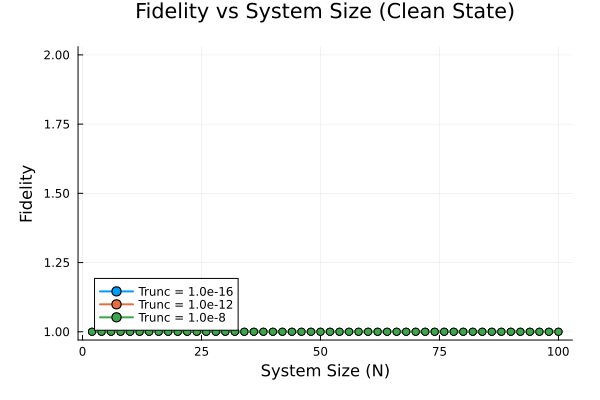

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\fid_clean_truncations.png"

In [51]:
p_fid = plot(
    title = "Fidelity vs System Size (Clean State)",
    xlabel = "System Size (N)",
    ylabel = "Fidelity",
    legend = :bottomleft, 
    margin = 5Plots.mm,
    grid = true
)

for trunc in target_truncs
    if haskey(all_data, trunc) && haskey(all_data[trunc], target_sigma)
        data = all_data[trunc][target_sigma]
        
        N_full = data["N_range"]
        
        # Accommodates both the new clean script output and the old array structure
        fid_full = haskey(data, "fidelities") ? data["fidelities"] : data["fid_avg"]
        
        mask = fid_full .> 0
        N_vals = N_full[mask]
        fid_vals = fid_full[mask]
        
        plot!(p_fid, N_vals, fid_vals, 
            label = "Trunc = $(trunc)", 
            marker = :circle, 
            linewidth = 2)
    else
        println("Warning: Data not found for Trunc = $trunc, σ = $target_sigma")
    end
end

display(p_fid)
savefig(p_fid, joinpath("images", "fid_clean_truncations.png"))

# Infidelity

In [52]:
"""
    get_infidelity_data(all_data, target_trunc, target_sigma)

Extracts system size (N), infidelity (beta), and error bars (if applicable) for a specific 
truncation and sigma from the loaded data dictionary.
"""
function get_infidelity_data(all_data, target_trunc, target_sigma)
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], target_sigma)
        data = all_data[target_trunc][target_sigma]
        
        N_full = data["N_range"]
        
        # 1. Handle Key Changes for Bond Dimensions (used for masking)
        bd_key = haskey(data, "bond_dims") ? "bond_dims" : "avg_arr"
        mask = data[bd_key] .> 0 
        
        N_vals = N_full[mask]
        
        # 2. Handle Key Changes for Fidelity
        fid_key = haskey(data, "fidelities") ? "fidelities" : "fid_avg"
        xi_vals = data[fid_key][mask] 
        
        # Calculate infidelity (beta)
        beta_vals = sqrt.(max.(0.0, 1.0 .- xi_vals.^2))
        
        # 3. Handle Errors (Only present in noisy/averaged data)
        if haskey(data, "fid_err")
            xi_errs = data["fid_err"][mask] 
            beta_errs = Float64[]
            for (x, b, dx) in zip(xi_vals, beta_vals, xi_errs)
                if b > 1e-10
                    push!(beta_errs, (x / b) * dx)
                else
                    push!(beta_errs, 0.0) 
                end
            end
            return N_vals, beta_vals, beta_errs
        else
            # Clean states have no standard deviation/error
            return N_vals, beta_vals, nothing 
        end
    else
        @warn "Data not found for Trunc = $target_trunc, σ = $target_sigma"
        return nothing
    end
end

get_infidelity_data

Note: Infidelity is exactly 0.0 for all N at Trunc = 1.0e-16
Note: Infidelity is exactly 0.0 for all N at Trunc = 1.0e-15
Note: Infidelity is exactly 0.0 for all N at Trunc = 1.0e-14
Note: Infidelity is exactly 0.0 for all N at Trunc = 1.0e-13
Note: Infidelity is exactly 0.0 for all N at Trunc = 1.0e-12
Note: Infidelity is exactly 0.0 for all N at Trunc = 1.0e-11
Note: Infidelity is exactly 0.0 for all N at Trunc = 1.0e-10
Note: Infidelity is exactly 0.0 for all N at Trunc = 1.0e-9
Note: Infidelity is exactly 0.0 for all N at Trunc = 1.0e-8


┌ Warning: Data not found for Trunc = 8.0e-16, σ = 0.0
└ @ Main In[52]:43
┌ Warning: Data not found for Trunc = 2.0e-15, σ = 0.0
└ @ Main In[52]:43
┌ Warning: Data not found for Trunc = 4.0e-15, σ = 0.0
└ @ Main In[52]:43
┌ Warning: Data not found for Trunc = 6.0e-15, σ = 0.0
└ @ Main In[52]:43
┌ Warning: Data not found for Trunc = 2.0e-14, σ = 0.0
└ @ Main In[52]:43
┌ Warning: Data not found for Trunc = 4.0e-14, σ = 0.0
└ @ Main In[52]:43
┌ Warning: Data not found for Trunc = 6.0e-14, σ = 0.0
└ @ Main In[52]:43
┌ Warning: Data not found for Trunc = 8.0e-14, σ = 0.0
└ @ Main In[52]:43
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packag

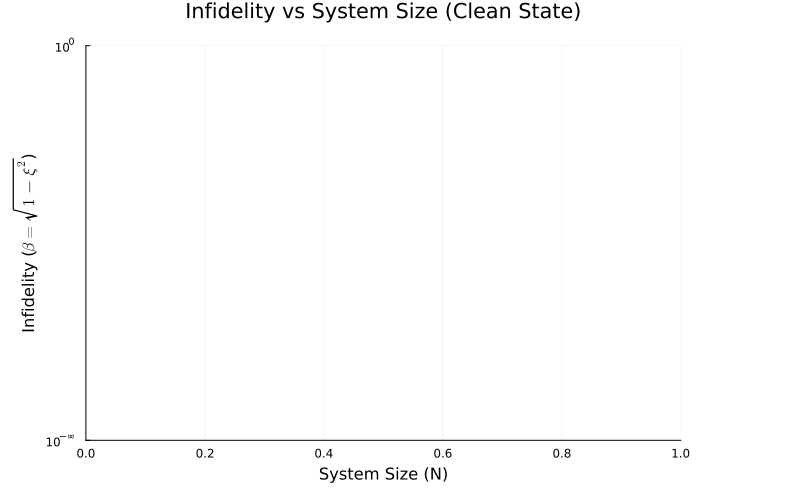

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194


"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\infid_clean_truncations.png"

In [53]:
target_truncs = [1e-16, 8e-16, 1e-15, 2e-15, 4e-15, 6e-15, 1e-14, 2e-14, 4e-14, 6e-14, 8e-14, 1e-13, 1e-12, 1e-11, 1e-10, 1e-9, 1e-8]
target_sigma = 0.0

p_infid = plot(
    title = "Infidelity vs System Size (Clean State)",
    xlabel = "System Size (N)",
    ylabel = L"Infidelity ($\beta = \sqrt{1 - \xi^2}$)",
    legend = :outertopright, 
    yscale = :log10, 
    grid = true,
    size = (800, 500),
    margin = 5Plots.mm
)

for trunc in target_truncs
    result = get_infidelity_data(all_data, trunc, target_sigma)
    if !isnothing(result)
        N_vals, beta_vals, beta_errs = result
        
        valid_mask = beta_vals .> 0.0
        
        if any(valid_mask)
            plot!(p_infid, N_vals[valid_mask], beta_vals[valid_mask], 
                label = "Trunc = $(trunc)", 
                marker = :circle, 
                markersize = 4,
                linewidth = 1.5)
        else
            println("Note: Infidelity is exactly 0.0 for all N at Trunc = $trunc")
        end
    end
end

display(p_infid)
savefig(p_infid, joinpath("images", "infid_clean_truncations.png"))

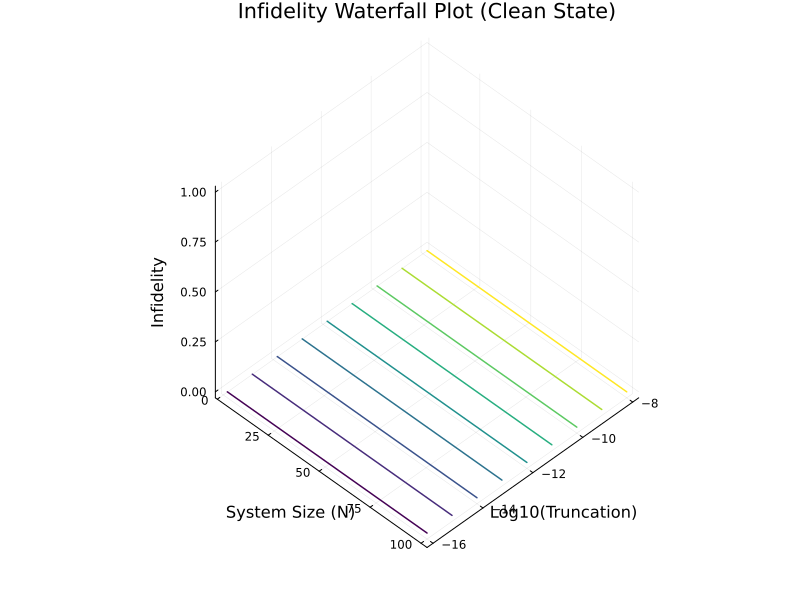

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\infid_waterfall_clean.png"

In [54]:
target_truncs = [1e-16, 8e-16, 1e-15, 2e-15, 4e-15, 6e-15, 1e-14, 2e-14, 4e-14, 6e-14, 8e-14, 1e-13, 1e-12, 1e-11, 1e-10, 1e-9, 1e-8]
target_sigma = 0.0

# Find which truncations actually exist in the loaded data for the clean state
valid_truncs = filter(trunc -> haskey(all_data, trunc) && haskey(all_data[trunc], target_sigma), target_truncs)
available_truncs = sort(valid_truncs)

if isempty(available_truncs)
    println("None of the chosen truncations were found for σ = $target_sigma.")
else
    p_waterfall_infid = plot(
        xlabel = "System Size (N)",
        ylabel = "Log10(Truncation)",
        zlabel = "Infidelity",
        title = "Infidelity Waterfall Plot (Clean State)",
        camera = (45, 45),
        legend = false,
        size = (800, 600)
    )
    
    line_colors = palette(:viridis, length(available_truncs))
    
    plot_count = 0
    
    for (idx, trunc) in enumerate(available_truncs)
        result = get_infidelity_data(all_data, trunc, target_sigma)
        
        if !isnothing(result)
            N_vals, beta_vals, _ = result
            
            if !isempty(N_vals)
                # Use log10 so the lines are evenly spaced visually
                Y_vals = fill(log10(trunc), length(N_vals))
                
                plot!(p_waterfall_infid, N_vals, Y_vals, beta_vals,
                      linecolor = line_colors[idx], linewidth = 1.5)
                
                plot_count += 1
            end
        end
    end
    
    if plot_count > 0
        display(p_waterfall_infid)
        savefig(p_waterfall_infid, joinpath("images", "infid_waterfall_clean.png"))
    else
        println("No valid infidelity data found to plot.")
    end
end

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194


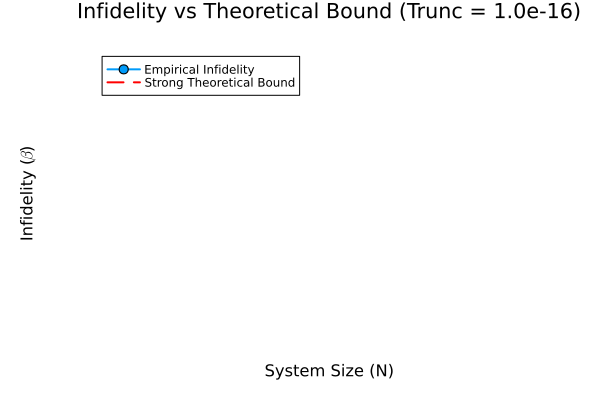

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Ethan\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194


"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\clean_error_bound_verification.png"

In [55]:
if haskey(all_data, target_trunc)
    result = get_infidelity_data(all_data, target_trunc, target_sigma)
    
    if !isnothing(result)
        N_vals, empirical_beta, _ = result
        
        valid_mask = empirical_beta .> 0.0
        N_valid = N_vals[valid_mask]
        beta_valid = empirical_beta[valid_mask]
        
        # Calculate theoretical strong bound for beta
        theoretical_beta_bound = [sqrt(strong_error_bound(Float64(N), target_trunc)) for N in N_valid]
        
        p_err = plot(
            title = "Infidelity vs Theoretical Bound (Trunc = $target_trunc)",
            xlabel = "System Size (N)",
            ylabel = L"Infidelity ($\beta$)",
            legend = :topleft,
            yscale = :log10,
            margin = 5Plots.mm,
            grid = true
        )
        
        plot!(p_err, N_valid, beta_valid, 
              label="Empirical Infidelity", marker=:circle, linewidth=2)
              
        plot!(p_err, N_valid, theoretical_beta_bound, 
              label="Strong Theoretical Bound", linestyle=:dash, linewidth=2, color=:red)
              
        display(p_err)
        savefig(p_err, joinpath("images", "clean_error_bound_verification.png"))
    end
end